In [2]:
from google.colab import drive
drive.mount('/content/drive')

!pip install timm

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import h5py
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split
import timm
import random
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

os.makedirs("/content/drive/MyDrive/morph_project/models", exist_ok=True)


Mounted at /content/drive
Using: cuda


In [ ]:
train_path = "/content/drive/MyDrive/morph_project/processed/train.h5"
test_path  = "/content/drive/MyDrive/morph_project/processed/test.h5"

with h5py.File(train_path, "r") as f:
    X = np.array(f["X"])
    y = np.array(f["y"])

with h5py.File(test_path, "r") as f:
    X_test = np.array(f["X"])
    y_test = np.array(f["y"])

print("Train:", X.shape, y.shape)
print("Test:", X_test.shape, y_test.shape)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


Train: (7177, 224, 224, 3) (7177,)
Test: (1803, 224, 224, 3) (1803,)


In [ ]:
img_size = 224

train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomResizedCrop(img_size, scale=(0.7,1.0)),
    transforms.AutoAugment(transforms.AutoAugmentPolicy.IMAGENET),
    transforms.ColorJitter(0.3,0.3,0.2,0.1),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.RandomGrayscale(p=0.1),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.3),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

val_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])


In [ ]:
class H5Dataset(Dataset):
    def __init__(self, X, y, transform=None):
        self.X = X
        self.y = y
        self.transform = transform

    def __len__(self): return len(self.X)

    def __getitem__(self, idx):
        img = self.X[idx]
        label = self.y[idx]
        return self.transform(img), torch.tensor(label)

train_loader = DataLoader(H5Dataset(X_train, y_train, train_transform),
                          batch_size=32, shuffle=True, num_workers=2)

val_loader = DataLoader(H5Dataset(X_val, y_val, val_transform),
                        batch_size=32, shuffle=False, num_workers=2)


In [ ]:
def mixup(x, y, alpha=0.4):
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(x.size(0))
    mixed_x = lam * x + (1 - lam) * x[idx]
    return mixed_x, y, y[idx], lam


In [ ]:
class ConvNeXtClassifier(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()

        self.backbone = timm.create_model(
            "convnextv2_tiny.fcmae_ft_in1k",
            pretrained=True,
            num_classes=0
        )

        in_features = self.backbone.num_features

        self.classifier = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.backbone(x))

model = ConvNeXtClassifier().to(device)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/115M [00:00<?, ?B/s]

In [ ]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = optim.AdamW(model.parameters(), lr=3e-5, weight_decay=1e-3)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=40,
    eta_min=1e-6
)


In [ ]:
epochs = 40
best_val_acc = 0
save_path = "/content/drive/MyDrive/morph_project/models/convnextv2_finetuned.pth"

train_losses, val_losses = [], []
train_accs, val_accs = [], []

def accuracy(o, y):
    return (torch.argmax(o, dim=1) == y).float().mean().item()

for epoch in range(epochs):

    model.train()
    tr_loss, tr_acc = 0.0, 0.0

    # ---------------- TRAINING ----------------
    for imgs, labels in train_loader:
        imgs = imgs.to(device)
        labels = labels.to(device).long()       # IMPORTANT FIX

        # Mixup
        imgs, y_a, y_b, lam = mixup(imgs, labels)
        y_a = y_a.long()
        y_b = y_b.long()

        optimizer.zero_grad()
        outputs = model(imgs)

        loss = lam * criterion(outputs, y_a) + (1 - lam) * criterion(outputs, y_b)
        loss.backward()
        optimizer.step()

        tr_loss += loss.item()

    train_losses.append(tr_loss / len(train_loader))


    # ---------------- VALIDATION ----------------
    model.eval()
    v_loss, v_acc = 0.0, 0.0

    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs = imgs.to(device)
            labels = labels.to(device).long()

            outputs = model(imgs)
            loss = criterion(outputs, labels)

            v_loss += loss.item()
            v_acc += accuracy(outputs, labels)

    val_losses.append(v_loss / len(val_loader))
    val_accs.append(v_acc / len(val_loader))


    # ---------------- LOGGING ----------------
    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"| Train Loss: {train_losses[-1]:.4f} "
        f"| Val Loss: {val_losses[-1]:.4f} "
        f"| Val Acc:  {val_accs[-1]:.4f}"
    )


    # ---------------- SAVE BEST MODEL ----------------
    if val_accs[-1] > best_val_acc:
        best_val_acc = val_accs[-1]
        torch.save(model.state_dict(), save_path)
        print("🔥 Saved BEST model to:", save_path)


    # ---------------- SCHEDULER UPDATE ----------------
    scheduler.step()

print("\n✅ Training completed!")
print("🏆 Best Validation Accuracy:", best_val_acc)


Epoch [1/40] | Train Loss: 0.5158 | Val Loss: 0.4995 | Val Acc:  0.8290
🔥 Saved BEST model to: /content/drive/MyDrive/morph_project/models/convnextv2_finetuned.pth
Epoch [2/40] | Train Loss: 0.5042 | Val Loss: 0.4957 | Val Acc:  0.8290
Epoch [3/40] | Train Loss: 0.4980 | Val Loss: 0.4822 | Val Acc:  0.8290
Epoch [4/40] | Train Loss: 0.4899 | Val Loss: 0.4861 | Val Acc:  0.8297
🔥 Saved BEST model to: /content/drive/MyDrive/morph_project/models/convnextv2_finetuned.pth
Epoch [5/40] | Train Loss: 0.4822 | Val Loss: 0.4857 | Val Acc:  0.8317
🔥 Saved BEST model to: /content/drive/MyDrive/morph_project/models/convnextv2_finetuned.pth
Epoch [6/40] | Train Loss: 0.4749 | Val Loss: 0.4673 | Val Acc:  0.8387
🔥 Saved BEST model to: /content/drive/MyDrive/morph_project/models/convnextv2_finetuned.pth
Epoch [7/40] | Train Loss: 0.4672 | Val Loss: 0.4591 | Val Acc:  0.8444
🔥 Saved BEST model to: /content/drive/MyDrive/morph_project/models/convnextv2_finetuned.pth
Epoch [8/40] | Train Loss: 0.4640 | 

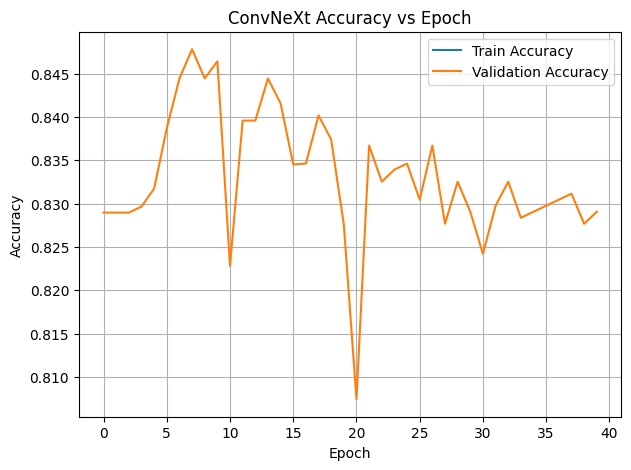

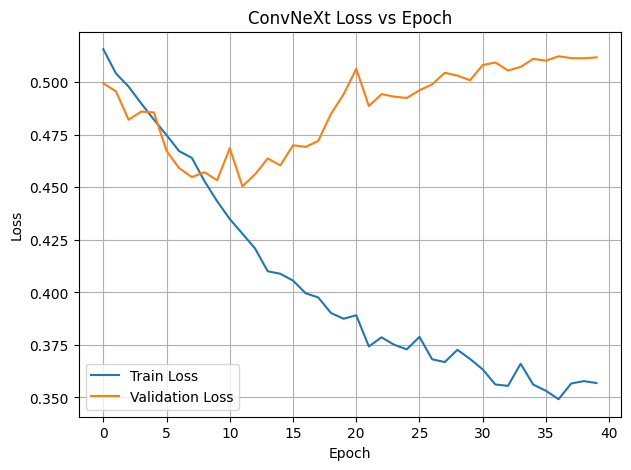

In [ ]:
import matplotlib.pyplot as plt

# Accuracy vs Epoch
plt.figure(figsize=(7,5))
plt.plot(train_accs, label="Train Accuracy")
plt.plot(val_accs, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ConvNeXt Accuracy vs Epoch")
plt.grid()
plt.legend()
plt.show()

# Loss vs Epoch
plt.figure(figsize=(7,5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ConvNeXt Loss vs Epoch")
plt.grid()
plt.legend()
plt.show()


In [ ]:
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report
import torch
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import h5py

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------------- Load Test Set ----------------
test_path = "/content/drive/MyDrive/morph_project/processed/test.h5"

with h5py.File(test_path, "r") as f:
    X_test = np.array(f["X"])
    y_test = np.array(f["y"])

img_size = 224

infer_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

class TestDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
    def __len__(self): return len(self.X)
    def __getitem__(self, idx):
        img = Image.fromarray(self.X[idx]).convert("RGB")
        return infer_transform(img), torch.tensor(self.y[idx]).long()

test_loader = DataLoader(TestDataset(X_test, y_test),
                         batch_size=32, shuffle=False)

# --------------- Load Best Finetuned Model ----------------
import timm
import torch.nn as nn

class ConvNeXtClassifier(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.backbone = timm.create_model(
            "convnextv2_tiny.fcmae_ft_in1k",
            pretrained=False,
            num_classes=0
        )
        in_features = self.backbone.num_features
        self.classifier = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, num_classes)
        )
    def forward(self, x):
        return self.classifier(self.backbone(x))

best_path = "/content/drive/MyDrive/morph_project/models/convnextv2_finetuned.pth"

model = ConvNeXtClassifier().to(device)
model.load_state_dict(torch.load(best_path, map_location=device))
model.eval()

# ---------------- Predictions ----------------
all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        probs = torch.softmax(outputs, 1)[:,1].cpu().numpy()
        preds = torch.argmax(outputs, 1).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(labels.numpy())
        all_probs.extend(probs)

# ---------------- Confusion Matrix ----------------
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d",
            xticklabels=["Licit","Illicit"],
            yticklabels=["Licit","Illicit"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ---------------- ROC Curve ----------------
fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], 'k--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.grid()
plt.legend()
plt.show()

print("\nClassification Report:")
print(classification_report(all_labels, all_preds))


In [ ]:
from google.colab import files

def predict_user_image(model, img_path):
    img = Image.open(img_path).convert("RGB")
    img_tensor = infer_transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(img_tensor)
        probs = torch.softmax(outputs, dim=1)
        pred = torch.argmax(probs, 1).item()

    classes = ["Licit", "Illicit"]

    print("\nImage:", img_path)
    print("Prediction:", classes[pred])
    print("Confidence:", round(float(probs[0][pred]), 4))

print("📌 Upload an image:")
uploaded = files.upload()

for filename in uploaded.keys():
    predict_user_image(model, filename)


In [5]:
import torch
import torch.nn as nn
import timm
import numpy as np
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import classification_report, confusion_matrix
from PIL import Image
import h5py

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

# ============================
# Load Test Dataset
# ============================

test_path = "/content/drive/MyDrive/morph_project/processed/test.h5"

with h5py.File(test_path, "r") as f:
    X_test = np.array(f["X"])
    y_test = np.array(f["y"])

img_size = 224

infer_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

class TestDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        img = self.X[idx]

        # ---- FIX 1: Remove extra dims ----
        img = np.squeeze(img)

        # ---- FIX 2: Convert floats to uint8 ----
        if img.dtype != np.uint8:
            img = (img * 255).astype(np.uint8)

        # ---- FIX 3: Ensure shape is (H, W, 3) ----
        if img.ndim == 2:
            img = np.stack([img]*3, axis=-1)

        # CHW → HWC conversion
        if img.ndim == 3 and img.shape[0] == 3:
            img = np.transpose(img, (1, 2, 0))

        # ---- Convert to PIL ----
        img = Image.fromarray(img)

        img = infer_transform(img)
        return img, torch.tensor(self.y[idx]).long()


# Create test loader
test_loader = DataLoader(TestDataset(X_test, y_test),
                         batch_size=32, shuffle=False)

# ============================
# Load Best Model
# ============================

class ConvNeXtClassifier(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.backbone = timm.create_model(
            "convnextv2_tiny.fcmae_ft_in1k",
            pretrained=False,
            num_classes=0
        )
        in_features = self.backbone.num_features
        self.classifier = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.backbone(x))

model_path = "/content/drive/MyDrive/morph_project/models/convnextv2_finetuned.pth"

model = ConvNeXtClassifier().to(device)
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()

print("Model Loaded Successfully!")

# ============================
# Run Predictions
# ============================

all_preds = []
all_labels = []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

# ============================
# Generate Precision, Recall, F1
# ============================

print("\n======================")
print("CLASSIFICATION REPORT")
print("======================")
print(classification_report(all_labels, all_preds,
                            target_names=["Licit", "Illicit"]))

print("\nConfusion Matrix:")
print(confusion_matrix(all_labels, all_preds))


Using: cuda
Model Loaded Successfully!

CLASSIFICATION REPORT
              precision    recall  f1-score   support

       Licit       0.85      0.98      0.91      1489
     Illicit       0.60      0.17      0.26       314

    accuracy                           0.84      1803
   macro avg       0.73      0.57      0.58      1803
weighted avg       0.81      0.84      0.79      1803


Confusion Matrix:
[[1455   34]
 [ 262   52]]
